5.0


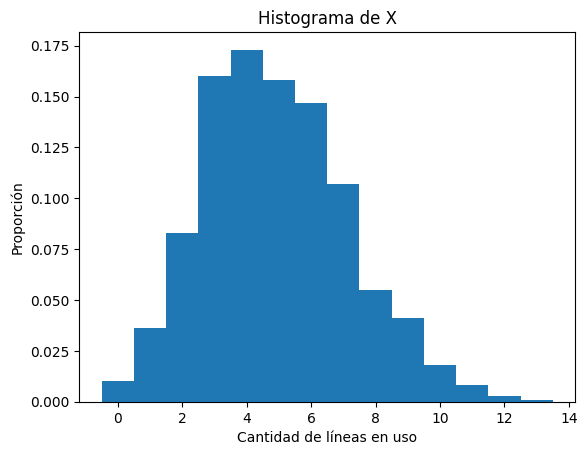

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
SEMILLA = 123
rng = np.random.default_rng(SEMILLA)

# Tarea 1 - Parte 2
## Primeros Estimadores
### Un fenómeno real: colas en un call center
lambda_ = 10
mu = 2
nu = lambda_ / mu
print(nu)

n = 1000
X = rng.poisson(lam=nu, size=n)

datos = pd.DataFrame({
    "X": X
})

datos.head()

plt.hist(X, bins=np.arange(X.min(), X.max() + 2) - 0.5, density=True)
plt.xlabel("Cantidad de líneas en uso")
plt.ylabel("Proporción")
plt.title("Histograma de X")

plt.show()

### Estimadores de media y varianza




### Estimadores de media y varianza

Para estimar la media de X usamos la media muestral:

$$
\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i
$$

Como X sigue una distribución Poisson, su esperanza es $E[X] = \nu$.


In [29]:
media_estimada = np.mean(X)

media_estimada

np.float64(4.921)

Para estimar la varianza usamos la varianza muestral:

$$
S_n^2 = \frac{1}{n-1}\sum_{i=1}^{n}(X_i-\bar{X}_n)^2
$$

Como X sigue una distribución Poisson, su varianza también es $\nu$.

In [30]:
varianza_estimada = np.var(X, ddof=1)

varianza_estimada

np.float64(5.059818818818819)

In [31]:
print("Media estimada:", media_estimada)
print("Varianza estimada:", varianza_estimada)
print("Valor de nu:", nu)

Media estimada: 4.921
Varianza estimada: 5.059818818818819
Valor de nu: 5.0


#### Insesgamiento y consistencia

La media muestral es insesgada porque:

$$
E[\bar{X}_n]
=
E\left[\frac{1}{n}\sum_{i=1}^{n}X_i\right]
=
\frac{1}{n}\sum_{i=1}^{n}E[X_i]
=
\frac{1}{n}(n\nu)
=
\nu
$$

Por lo tanto, $\bar{X}_n$ es un estimador insesgado de $\nu$.

Además, por la Ley de los Grandes Números,

$$
\bar{X}_n \longrightarrow \nu
$$

cuando aumenta n, por lo que también es consistente.

La varianza muestral corregida también es un estimador insesgado de la varianza de X.

Como para una distribución Poisson se cumple que:

$$
Var(X)=\nu
$$

entonces $S_n^2$ también permite estimar $\nu$.

Además, al aumentar el tamaño de la muestra, la varianza muestral se aproxima a la varianza real, por lo que es consistente.

In [32]:
medias = datos["X"].expanding().mean()

varianzas = datos["X"].expanding().var(ddof=1)



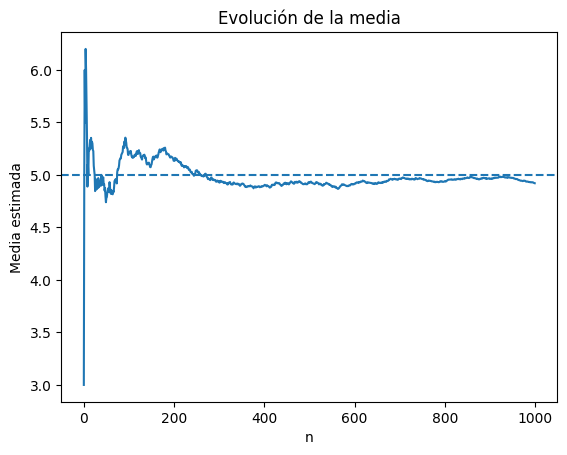

In [33]:
plt.plot(medias)
plt.axhline(nu, linestyle="--")

plt.xlabel("n")
plt.ylabel("Media estimada")
plt.title("Evolución de la media")

plt.show()

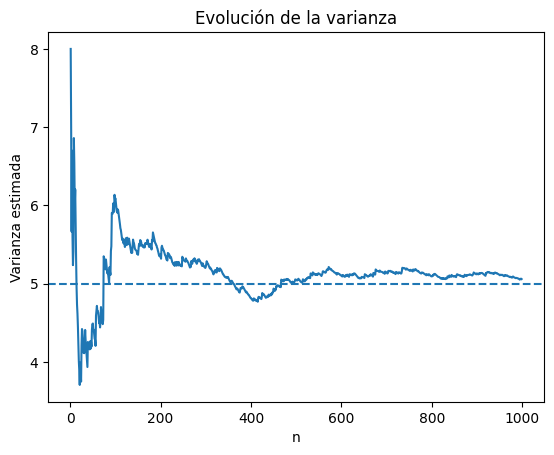

In [34]:
plt.plot(varianzas)
plt.axhline(nu, linestyle="--")

plt.xlabel("n")
plt.ylabel("Varianza estimada")
plt.title("Evolución de la varianza")

plt.show()

Vemos que tanto la media como la varianza se acercan al valor real de $\nu=5$ a medida que aumenta el tamaño de la muestra.

La media parece estabilizarse más rápido y presenta menos variaciones que la varianza. Por esto mismo preferimos usar la media en vez de la varianza.


### Identificabilidad

El modelo depende de los parámetros $\lambda$ y $\mu$ solamente a través de

$$
\nu = \frac{\lambda}{\mu}.
$$

Por lo tanto, no es posible identificar $\lambda$ y $\mu$ individualmente usando solamente las observaciones de X.

Por ejemplo, los pares $(\lambda,\mu)=(10,2)$ y $(20,4)$ producen el mismo valor $\nu=5$, por lo que generan la misma distribución Poisson.

Entonces, el parámetro que sí podemos identificar a partir de los datos es $\nu$.

### Estimación de la probabilidad de sistema vacío

Queremos estimar

$$
g(\nu)=P(X=0).
$$

Como $X$ sigue una distribución Poisson,

$$
P(X=k)=e^{-\nu}\frac{\nu^k}{k!}.
$$

Tomando $k=0$:

$$
g(\nu)=P(X=0)=e^{-\nu}.
$$

In [35]:
g_real = np.exp(-nu)

g_real

np.float64(0.006737946999085467)

#### Estimador 1

Para una variable aleatoria Poisson se cumple que:

$$
E[X] = \nu
$$

Por método de momentos, el estimador de $\nu$ es:

$$
\hat{\nu}_{MM} = \bar{X}
$$

Además, usando máxima verosimilitud para una variable de Poisson se obtiene el mismo estimador:

$$
\hat{\nu}_{MV} = \bar{X}
$$

Como queremos estimar

$$
g(\nu) = e^{-\nu},
$$

reemplazamos $\nu$ por su estimador $\bar{X}$. Entonces obtenemos:

$$
\hat{g}_1 = e^{-\bar{X}}.
$$

In [36]:
g1 = np.exp(-media_estimada)

g1

np.float64(0.0072918353642909975)

¿Es insesgado? Este estimador no es insesgado, ya que en general

$$
E[e^{-\bar{X}_n}] \neq e^{-E[\bar{X}_n]}.
$$

Sin embargo, es consistente porque $\bar{X}_n$ converge a $\nu$ y, por lo tanto, $e^{-\bar{X}_n}$ converge a $e^{-\nu}$.
Ahora intentamos con otro estimador

#### Estimador 2

Otra forma de estimar $g(\nu)=P(X=0)$ es mirar directamente cuántas veces aparece el valor 0 en la muestra.

Si tenemos $n$ observaciones, contamos cuántas de ellas son iguales a 0 y dividimos esa cantidad por $n$. Así obtenemos la proporción de veces en que el sistema está vacío.

Para escribir esto matemáticamente usamos la indicatriz:

$$
\mathbf{1}_{\{X_i=0\}} =
\begin{cases}
1, & \text{si } X_i=0 \\
0, & \text{si } X_i\neq 0
\end{cases}
$$

Entonces el estimador es:

$$
\hat{g}_2 =
\frac{1}{n}\sum_{i=1}^{n}\mathbf{1}_{\{X_i=0\}}.
$$

Este estimador es simplemente a la proporción de ceros observados en la muestra.

In [37]:
g2 = np.mean(X == 0)

g2

np.float64(0.01)

¿Es insesgado? Este estimador es

$$
\hat g_2=\frac1n\sum_{i=1}^n \mathbf 1_{\{X_i=0\}}.
$$

Como

$$
E[\mathbf 1_{\{X_i=0\}}]=P(X_i=0)=g(\nu),
$$

entonces, por linealidad de la esperanza,

$$
E[\hat g_2]
=
E\left[\frac1n\sum_{i=1}^n \mathbf 1_{\{X_i=0\}}\right]
=
\frac1n\sum_{i=1}^n E[\mathbf 1_{\{X_i=0\}}]
=
\frac1n\sum_{i=1}^n g(\nu)
=
g(\nu).
$$

Por lo tanto, $\hat g_2$ es un estimador insesgado de $g(\nu)$.


#### Estimador 3

Para construir un tercer estimador usamos el método de momentos, pero esta vez usamos el segundo momento.

Sabemos que para una variable aleatoria Poisson:

$$
E[X]=\nu
$$

y

$$
Var(X)=\nu.
$$

Usando la relación

$$
Var(X)=E[X^2]-E[X]^2,
$$

obtenemos

$$
E[X^2]=\nu+\nu^2.
$$

El segundo momento muestral es

$$
m_2=\frac{1}{n}\sum_{i=1}^{n}X_i^2.
$$

Por método de momentos igualamos:

$$
m_2=\nu+\nu^2.
$$

Por lo tanto,

$$
\nu^2+\nu-m_2=0.
$$

Resolviendo esta ecuación y tomando la solución positiva:

$$
\hat{\nu}_2=
\frac{-1+\sqrt{1+4m_2}}{2}.
$$

Finalmente, como $g(\nu)=e^{-\nu}$, definimos

$$
\hat{g}_3=e^{-\hat{\nu}_2}.
$$

In [38]:
m2 = np.mean(X**2)

nu_estimado_2 = (-1 + np.sqrt(1 + 4*m2)) / 2

g3 = np.exp(-nu_estimado_2)

g3

np.float64(0.0072025286849551244)

¿Es insesgado?

El tercer estimador es

$$
\hat g_3=e^{-\hat\nu_2},
$$

donde

$$
\hat\nu_2=
\frac{-1+\sqrt{1+4m_2}}{2}
$$

y

$$
m_2=\frac{1}{n}\sum_{i=1}^n X_i^2.
$$

Sabemos que

$$
E[m_2]=E[X^2]=\nu+\nu^2.
$$

Pero para obtener $\hat\nu_2$ aplicamos una función no lineal a $m_2$. Por lo tanto, en general,

$$
E[\hat\nu_2]
\neq
\frac{-1+\sqrt{1+4E[m_2]}}{2}
=
\nu.
$$

Además, el estimador de $g(\nu)$ aplica nuevamente una función no lineal:

$$
\hat g_3=e^{-\hat\nu_2}.
$$

Por esto, en general,

$$
E[\hat g_3]\neq e^{-\nu}=g(\nu).
$$

Entonces, el estimador $\hat g_3$ no es insesgado.

In [39]:
n_valores = np.arange(1, len(X) + 1)

# Estimador 1
media_n = np.cumsum(X) / n_valores
g1_n = np.exp(-media_n)

# Estimador 2
g2_n = np.cumsum(X == 0) / n_valores

# Estimador 3
m2_n = np.cumsum(X**2) / n_valores
nu2_n = (-1 + np.sqrt(1 + 4*m2_n)) / 2
g3_n = np.exp(-nu2_n)

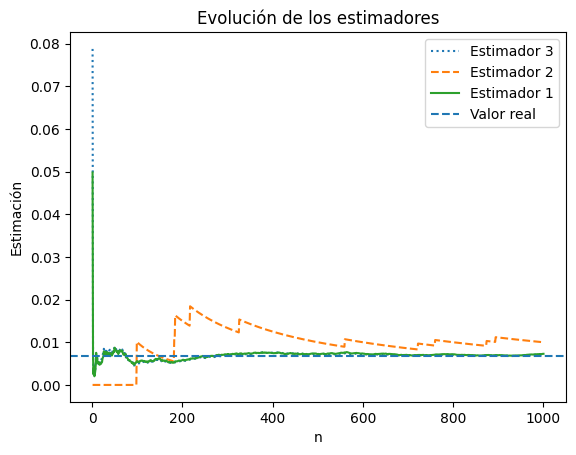

In [48]:
plt.plot(n_valores, g3_n, ":", label="Estimador 3")
plt.plot(n_valores, g2_n, "--", label="Estimador 2")
plt.plot(n_valores, g1_n, label="Estimador 1")
plt.axhline(g_real, linestyle="--", label="Valor real")

plt.xlabel("n")
plt.ylabel("Estimación")
plt.title("Evolución de los estimadores")
plt.legend()
plt.show()

#### Consistencia de los estimadores

Los tres estimadores se acercan al valor real de $g(\nu)$ ~ 0,0067 cuando aumenta el tamaño de la muestra.

Para el estimador 1, por la Ley de los Grandes Números,

$$
\bar X_n \longrightarrow \nu,
$$

por lo que

$$
e^{-\bar X_n} \longrightarrow e^{-\nu}.
$$

Para el estimador 2, la proporción de observaciones iguales a cero converge a

$$
P(X=0)=g(\nu).
$$

Para el estimador 3, el segundo momento muestral converge a

$$
E[X^2]=\nu+\nu^2.
$$

Por lo tanto, el estimador de $\nu$ obtenido a partir del segundo momento converge a $\nu$, y así

$$
\hat g_3 \longrightarrow e^{-\nu}.
$$

Así los tres estimadores son consistentes.

El hecho de que un estimador sea insesgado es importante, pero no es la única cosa que se debe considerar.

En este caso, el estimador 2 es insesgado, mientras que los estimadores 1 y 3 presentan sesgo. Aun así los tres son consistentes (de hecho el estimador 2 parece estabilizarse más lentamente alrededor del valor real), por lo que al aumentar el tamaño de la muestra se acercan al valor real de $g(\nu)$.

Por esto, además del sesgo, también es importante considerar cómo se comporta el estimador cuando aumenta el tamaño de la muestra y cuánto varía entre distintas muestras.

In [49]:
datos_reales = pd.read_csv("datos_cola (1).csv")

datos_reales.head()

,Unnamed: 0,samples
0,0,1
1,1,4
2,2,3
3,3,6
4,4,3


In [50]:
X_real = datos_reales["samples"]

X_real.head()

,samples
0,1
1,4
2,3
3,6
4,3


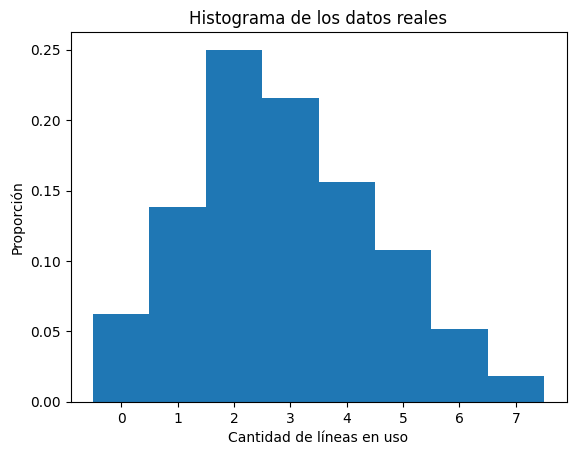

In [51]:
plt.hist(X_real, bins=np.arange(X_real.min(), X_real.max() + 2) - 0.5, density=True)

plt.xlabel("Cantidad de líneas en uso")
plt.ylabel("Proporción")
plt.title("Histograma de los datos reales")

plt.show()

In [55]:
nu_estimado = np.mean(X_real)

nu_estimado

np.float64(2.888)

In [53]:
print("Media:", np.mean(X_real))
print("Varianza:", np.var(X_real, ddof=1))

Media: 2.888
Varianza: 2.6968496993988


### Ajuste a los datos reales

A partir del gráfico, los datos tienen una forma parecida a la vista anteriormente para una distribución Poisson. Además, los datos corresponden a valores enteros no negativos.

Para una distribución Poisson se cumple que la media y la varianza son iguales. En los datos obtuvimos:

$$
\bar X = 2.888
$$

y una varianza muestral aproximada de

$$
S^2 = 2.697.
$$

Como ambos valores son muy parecidos, podemos estudiar los datos con una distribución Poisson.

Para estimar el parámetro de la distribución usamos la media:

$$
\hat{\nu}=\bar X=2.888.
$$

In [56]:
g_datos = np.exp(-nu_estimado)

g_datos

np.float64(0.05568747626326995)

Para esta parte usamos el estimador 1,

$$
\hat g_1=e^{-\bar X}.
$$

Elegimos este estimador porque usa el parámetro de la distribución Poisson que estimamos mediante la media.


Usando el estimador 1 y el valor estimado $\hat{\nu}=2.888$, obtenemos

$$
\hat g=e^{-2.888}\approx 0.0557.
$$

Por lo tanto, la probabilidad estimada de que no haya líneas activas es aprox $5.57\%$.